In [78]:
import os
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from afolu.assets.constants import LABEL_LIST
from matplotlib.axes import Axes

In [79]:
data_path = Path(os.environ["DATA_PATH"])
out_path = data_path / "generated"

In [80]:
ZONE = "PER+Coronel Portillo"

In [81]:
import geopandas as gpd
bbox = gpd.read_file(out_path / "small" / "bbox" / "shapely" / f"{ZONE}.gpkg")
bbox.to_crs("ESRI:102033").area.item() / 1e4

85432.09230182867

# Área

Cargamos las DataFrame de área:

In [82]:
def load_area_df(fpath: os.PathLike) -> pd.DataFrame:
    return (
        pd.read_csv(fpath)
        .set_index("label")
        .transpose()
        .reset_index(names="index")
        .assign(index=lambda df: df["index"].astype(int) + 2000)
        .rename(columns={"index": "year"})
        .query("year <= 2035")
        .set_index("year")
        .divide(100)
    )

In [83]:
df_normal = load_area_df(out_path / "small" / "forecast" / "area" / "normal" / f"{ZONE}.csv")
df_fast = load_area_df(out_path / "small" / "forecast" / "area" / "fast" / f"{ZONE}.csv")
df_slow = load_area_df(out_path / "small" / "forecast" / "area" / "slow" / f"{ZONE}.csv")

In [84]:
df_normal_frac = df_normal.div(df_normal.sum(axis=1), axis=0)
df_fast_frac = df_fast.div(df_fast.sum(axis=1), axis=0)
df_slow_frac = df_slow.div(df_slow.sum(axis=1), axis=0)

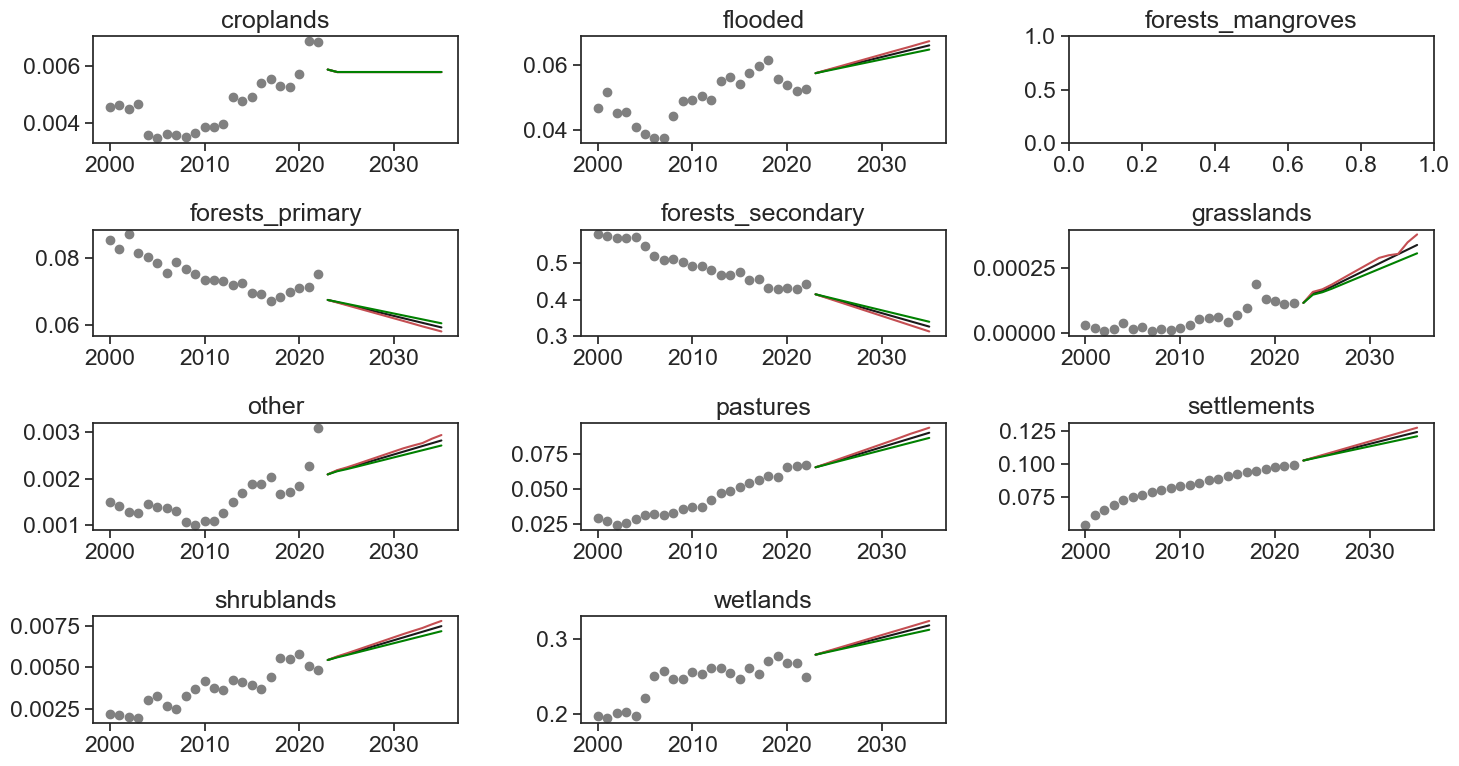

In [85]:
fig, axes = plt.subplots(4, 3, figsize=(15, 8))

for label, ax in zip(LABEL_LIST, axes.flatten(), strict=False):
    ax.set_title(label)
    if label == "forests_mangroves":
        continue
    df_normal_frac.loc[:2022, label].plot(ax=ax, color="gray", marker="o", linestyle="None")
    df_normal_frac.loc[2023:, label].plot(ax=ax, color="k")
    df_fast_frac.loc[2023:, label].plot(ax=ax, c="r")
    df_slow_frac.loc[2023:, label].plot(ax=ax, c="green")
    ax.set_xlabel("")

axes[-1, -1].axis("off")

fig.tight_layout()

Graficamos los escenarios

In [86]:
def plot_scenarios(
    series_fast: pd.Series,
    series_normal: pd.Series,
    series_slow: pd.Series, *,
    ax: Axes,
    scatter: bool=False,
    legend: bool=True,
    plot_normal: bool=True,
    plot_slow: bool=True,
    plot_fast: bool=True
) -> None:
    historical = series_fast.loc[:2022]

    fast = series_fast.loc[2023:]
    normal = series_normal.loc[2023:]
    slow = series_slow.loc[2023:]

    if scatter:
        historical.plot(ax=ax, label="Histórico", color="gray", marker='o', linestyle='None')
    else:
        historical.plot(ax=ax, label="Histórico", color="gray")

    if plot_fast:
        fast.plot(ax=ax, label="Acelerado", color="red")

    if plot_normal:
        normal.plot(ax=ax, label="Normal", color="black")

    if plot_slow:
        slow.plot(ax=ax, label="Desacelerado", color="green")

    if legend:
        ax.legend()

## Bosques

Text(0.5, 1.0, 'Bosques')

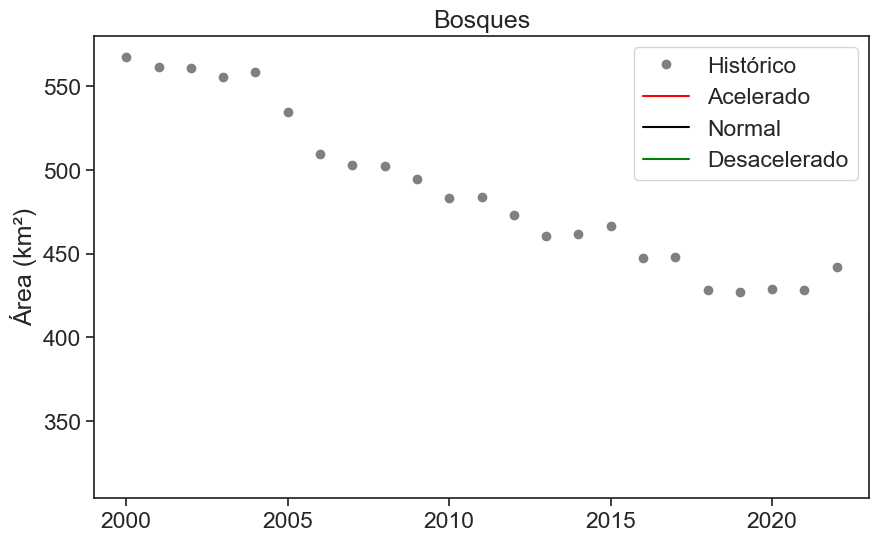

In [87]:
forest_fast = df_fast["forests_primary"] + df_fast["forests_secondary"]
forest_normal = df_normal["forests_primary"] + df_normal["forests_secondary"]
forest_slow = df_slow["forests_primary"] + df_slow["forests_secondary"]

fig, ax = plt.subplots(figsize=(10, 6))
plot_scenarios(forest_fast, forest_normal, forest_slow, ax=ax, scatter=True)

ax.set_xlim(1999, 2023)
ax.set_xlabel("")
ax.set_ylabel("Área (km²)")
ax.set_title("Bosques")

## Asentamientos

Text(0.5, 1.0, 'Asentamientos')

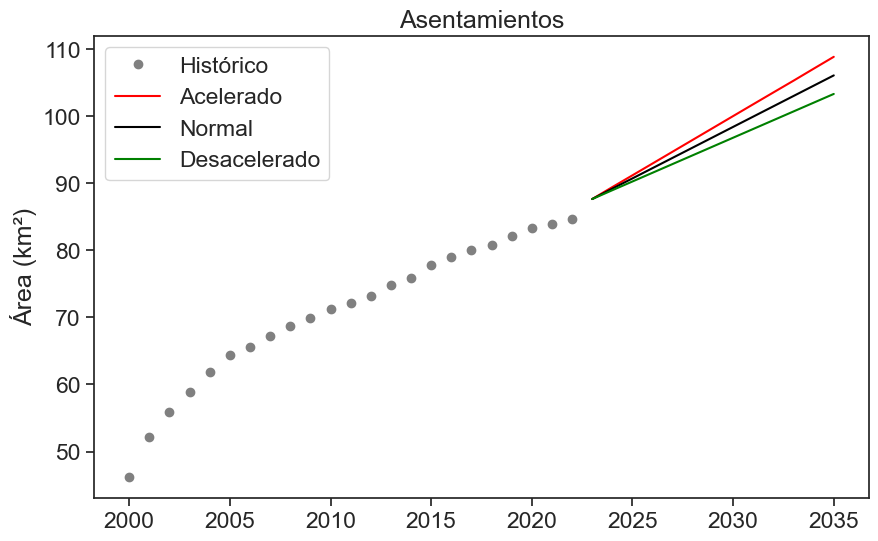

In [88]:
sns.set_theme(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(10, 6))
plot_scenarios(df_fast["settlements"], df_normal["settlements"], df_slow["settlements"], ax=ax, scatter=True, legend=True)

ax.set_xlabel("")
ax.set_ylabel("Área (km²)")
ax.set_title("Asentamientos")

# Diferencia de captura entre escenarios

In [89]:
def load_emission_df(fpath: os.PathLike) -> pd.DataFrame:
    return (
        pd.read_csv(fpath)
        .assign(time_period=lambda df: df["time_period"].astype(int) + 2000)
        .rename(columns={"time_period": "year"})
        .query("year <= 2035")
        .set_index("year")
    )

df_emissions_fast = load_emission_df(out_path / "small" / "forecast" / "emissions" / "fast" / f"{ZONE}.csv")
df_emissions_normal = load_emission_df(out_path / "small" / "forecast" / "emissions" / "normal" / f"{ZONE}.csv")
df_emissions_slow = load_emission_df(out_path / "small" / "forecast" / "emissions" / "slow" / f"{ZONE}.csv")

In [90]:
sequestration_columns = [
    "emission_co2e_co2_lndu_biomass_sequestration_grasslands",
    "emission_co2e_co2_lndu_biomass_sequestration_other",
    "emission_co2e_co2_lndu_biomass_sequestration_pastures",
    "emission_co2e_co2_lndu_biomass_sequestration_settlements",
    "emission_co2e_co2_lndu_biomass_sequestration_shrublands",
    "emission_co2e_co2_lndu_biomass_sequestration_wetlands",
    "emission_co2e_subsector_total_frst",
]

In [91]:
sequestration_fast = df_emissions_fast[sequestration_columns].sum(axis=1).abs().mul(1000)
sequestration_normal = df_emissions_normal[sequestration_columns].sum(axis=1).abs().mul(1000)
sequestration_slow = df_emissions_slow[sequestration_columns].sum(axis=1).abs().mul(1000)

<Axes: xlabel='year'>

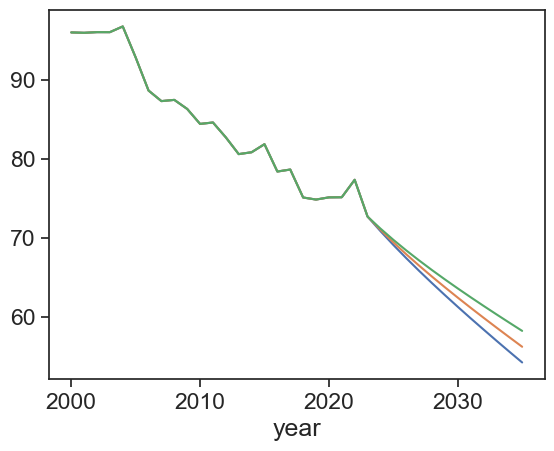

In [92]:
sequestration_fast.plot()
sequestration_normal.plot()
sequestration_slow.plot()

Text(0, 0.5, 'Carbono capturado (miles de toneladas)')

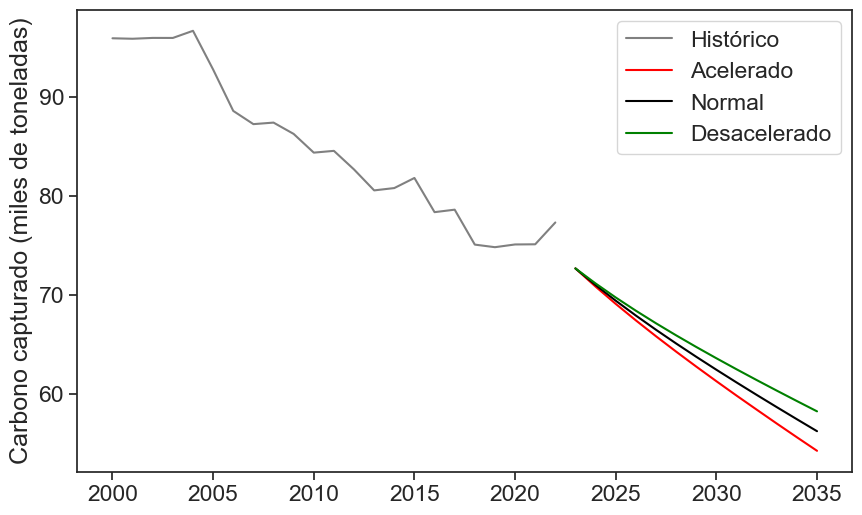

In [93]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_scenarios(sequestration_fast, sequestration_normal, sequestration_slow, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Carbono capturado (miles de toneladas)")

In [94]:
df_emissions_fast[[c for c in df_emissions_fast.columns if "emission_co2e" in c and "lndu" in c]]

,emission_co2e_co2_lndu_conversion_away_croplands,emission_co2e_co2_lndu_conversion_away_flooded,emission_co2e_co2_lndu_conversion_away_forests_mangroves,emission_co2e_co2_lndu_conversion_away_forests_primary,emission_co2e_co2_lndu_conversion_away_forests_secondary,emission_co2e_co2_lndu_conversion_away_grasslands,emission_co2e_co2_lndu_conversion_away_other,emission_co2e_co2_lndu_conversion_away_pastures,emission_co2e_co2_lndu_conversion_away_settlements,emission_co2e_co2_lndu_conversion_away_shrublands,...,emission_co2e_co2_lndu_conversion_wetlands_to_forests_mangroves,emission_co2e_co2_lndu_conversion_wetlands_to_forests_primary,emission_co2e_co2_lndu_conversion_wetlands_to_forests_secondary,emission_co2e_co2_lndu_conversion_wetlands_to_grasslands,emission_co2e_co2_lndu_conversion_wetlands_to_other,emission_co2e_co2_lndu_conversion_wetlands_to_pastures,emission_co2e_co2_lndu_conversion_wetlands_to_settlements,emission_co2e_co2_lndu_conversion_wetlands_to_shrublands,emission_co2e_co2_lndu_conversion_wetlands_to_wetlands,emission_co2e_subsector_total_lndu
year,,,,,,,,,,,,,,,,,,,,,
2000,0.0,0.0,0.0,0.0,0.753137,3.532258e-06,0.0,0.000416,0.0,0.001046,...,0.0,0.0,0.0,0.0,0.000060,0.0,0.000018,0.0,0.0,0.796023
2001,0.0,0.0,0.0,0.0,0.752217,1.116929e-06,0.0,0.000211,0.0,0.000748,...,0.0,0.0,0.0,0.0,0.000059,0.0,0.000014,0.0,0.0,0.792306
2002,0.0,0.0,0.0,0.0,0.764439,0.000000e+00,0.0,0.000143,0.0,0.001077,...,0.0,0.0,0.0,0.0,0.000070,0.0,0.000014,0.0,0.0,0.806034
2003,0.0,0.0,0.0,0.0,0.752942,1.561376e-07,0.0,0.000138,0.0,0.000991,...,0.0,0.0,0.0,0.0,0.000079,0.0,0.000015,0.0,0.0,0.793499
2004,0.0,0.0,0.0,0.0,0.911364,0.000000e+00,0.0,0.000096,0.0,0.002889,...,0.0,0.0,0.0,0.0,0.000048,0.0,0.000007,0.0,0.0,0.952192
2005,0.0,0.0,0.0,0.0,0.887401,0.000000e+00,0.0,0.000086,0.0,0.002313,...,0.0,0.0,0.0,0.0,0.000062,0.0,0.000006,0.0,0.0,0.931817
2006,0.0,0.0,0.0,0.0,0.804249,6.262362e-07,0.0,0.000090,0.0,0.001741,...,0.0,0.0,0.0,0.0,0.000069,0.0,0.000004,0.0,0.0,0.854080
2007,0.0,0.0,0.0,0.0,0.716217,0.000000e+00,0.0,0.000068,0.0,0.001207,...,0.0,0.0,0.0,0.0,0.000071,0.0,0.000010,0.0,0.0,0.767965
2008,0.0,0.0,0.0,0.0,0.702806,4.631623e-07,0.0,0.000064,0.0,0.002270,...,0.0,0.0,0.0,0.0,0.000062,0.0,0.000009,0.0,0.0,0.752995


In [95]:
df_emissions_fast / df_fast

,area_agrc_crops_bevs_and_spices,area_agrc_crops_cereals,area_agrc_crops_fibers,area_agrc_crops_fruits,area_agrc_crops_herbs_and_other_perennial_crops,area_agrc_crops_nuts,area_agrc_crops_other_annual,area_agrc_crops_other_woody_perennial,area_agrc_crops_pulses,area_agrc_crops_rice,...,yield_agrc_fruits_tonne,yield_agrc_herbs_and_other_perennial_crops_tonne,yield_agrc_nuts_tonne,yield_agrc_other_annual_tonne,yield_agrc_other_woody_perennial_tonne,yield_agrc_pulses_tonne,yield_agrc_rice_tonne,yield_agrc_sugar_cane_tonne,yield_agrc_tubers_tonne,yield_agrc_vegetables_and_vines_tonne
year,,,,,,,,,,,,,,,,,,,,,
2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [96]:
(sequestration_slow - sequestration_normal).sum()

np.float64(12.966269781824089)

In [97]:
print(f"Si se lograse desacelerar la urbanización y deforestación por un 20%, se capturarían {(sequestration_slow - sequestration_normal).sum():,.0f} mil toneladas de CO₂ más que en el escenario normal.")

Si se lograse desacelerar la urbanización y deforestación por un 20%, se capturarían 13 mil toneladas de CO₂ más que en el escenario normal.
